In [58]:
"""
Most up to date and improved code that plots the results from ProSpect SED fitting, along with data calculated from Shay.
It was getting to long so some of the plotting is continued in More_plotting.ipynb.
"""


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
import csv
from decimal import Decimal
from IPython.display import display, Math
import math
import os
import emcee
import corner
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator

FIG_DIR = "/nvme/scratch/work/alberttg/Summer_project/Plots"

OUTPUT_DIR = "/nvme/scratch/work/alberttg/Summer_project/Data_products"

FILTERS =["F115W", "F150W", "F200W", "F277W", "F356W", "F444W", "F606W", "F814W"]

In [59]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [60]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [61]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params,
                                  x_obs=None, x_err_low=None, x_err_high=None,
                                  gradient=None):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties,
    optionally including x uncertainties projected onto y via the model gradient.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    y_model : array_like
        Model predictions.
    n_params : int
        Number of fitted parameters.
    x_obs : array_like, optional
        Observed x values. Required if x_err_low/x_err_high are given.
    x_err_low : array_like, optional
        Lower (negative) uncertainties on x. If None, treated as zero.
    x_err_high : array_like, optional
        Upper (positive) uncertainties on x. If None, treated as zero.
    gradient : float, optional
        Local gradient of the model (dy/dx), used to project x uncertainty
        onto y. Required if x uncertainties are non-zero.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err_low = np.asarray(y_err_low, dtype=float)
    y_err_high = np.asarray(y_err_high, dtype=float)

    # Use the appropriate uncertainty depending on which side of the data
    sigma_y = np.where(y_model > y_obs, y_err_high, y_err_low)

    # Handle x uncertainties, if provided
    if x_err_low is None:
        x_err_low = np.zeros_like(y_obs)
    else:
        x_err_low = np.asarray(x_err_low, dtype=float)

    if x_err_high is None:
        x_err_high = np.zeros_like(y_obs)
    else:
        x_err_high = np.asarray(x_err_high, dtype=float)

    # If x errors are all zero, skip the x-error projection entirely —
    # this avoids requiring x_obs/gradient when there's nothing to project
    if np.all(x_err_low == 0) and np.all(x_err_high == 0):
        sigma = sigma_y
    else:
        if x_obs is None or gradient is None:
            raise ValueError("x_obs and gradient must be provided when x uncertainties are non-zero.")

        x_obs = np.asarray(x_obs, dtype=float)
        sigma_x = np.where(y_model > y_obs, x_err_high, x_err_low)

        # project x uncertainty onto y using the model gradient, combine in quadrature
        sigma = np.sqrt(sigma_y**2 + (gradient * sigma_x)**2)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [62]:
def calculate_nmad(y, y_err_high, y_err_low, y_model, x_err_high, x_err_low, gradient, int_scatter):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    y_sigma = np.where(
        residuals > 0,
        y_err_low,   # data lie above model
        y_err_high   # data lie below model
    )

    if x_err_high is None or x_err_low is None or gradient is None:
        x_err_high = np.zeros_like(y)
        x_err_low = np.zeros_like(y)
        gradient = 0.0

    if int_scatter is None:
        int_scatter = 0.0
    
    if gradient >= 0:
        x_sig = np.where(residuals >= 0, x_err_high, x_err_low)
        # If residual is positive and slope is positive, use upper x error
    else:
        x_sig = np.where(residuals >= 0, x_err_low, x_err_high)
        # if residual is negative and slope is negative, use upper x error.
        # if residual is positive and slope is negative, use lower x error.

    total_sigma = np.sqrt(y_sigma**2 + (gradient * x_sig)**2 + int_scatter**2)

    normalised_residuals = residuals / total_sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [63]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [64]:
def _parse_err(err, n):
    """
    Normalize an error specification into (err_lo, err_hi) arrays of length n.

    Accepted forms for `err`:
      - None                            -> zeros (no error)
      - scalar or 1D array of length n  -> symmetric error (same as before)
      - [err_high, err_low]             -> asymmetric error; each of
        err_high/err_low can be a scalar (applied to all points) or a
        length-n array (per-point)

    Returned lo/hi are positive distances from the central value
    (lower bound = value - lo, upper bound = value + hi).
    """
    if err is None:
        return np.zeros(n), np.zeros(n)

    # Asymmetric: [err_high, err_low]
    if isinstance(err, (list, tuple)) and len(err) == 2:
        hi = np.asarray(err[0], dtype=float)
        lo = np.asarray(err[1], dtype=float)
        if hi.ndim == 0:
            hi = np.full(n, float(hi))
        if lo.ndim == 0:
            lo = np.full(n, float(lo))
        return lo.copy(), hi.copy()

    # Symmetric: scalar or array, same as before
    arr = np.asarray(err, dtype=float)
    if arr.ndim == 0:
        arr = np.full(n, float(arr))
    return arr.copy(), arr.copy()


def fit_linear_mcmc(x_in, y_in, x_err=None, y_err=None, x_pivot=None,
                     n_walkers=50, n_steps=10000, plot=False, save_path=None):
    """
    Bayesian linear fit y = m*(x - x_pivot) + c with intrinsic scatter,
    supporting asymmetric measurement errors in both x and y.

    x_err / y_err each accept:
      - None, a scalar, or a 1D array of length N (symmetric errors, same
        as before), OR
      - [err_high, err_low] for asymmetric errors, where each of
        err_high/err_low is a scalar (applied to every point) or a
        length-N array (per-point).

    Asymmetric-error handling
    --------------------------
    Each data point's error distribution is modeled as a split-normal
    (two-piece Gaussian): width `sigma_lo` below the measured value and
    `sigma_hi` above it. At every MCMC step, for each point we compare the
    model prediction to the data (delta = model - data) and pick the
    error side consistent with that comparison:
        delta >= 0  ->  use the "hi" error (model sits above the data)
        delta <  0  ->  use the "lo" error (model sits below the data)
    This is applied to both the y errors and the x errors (the latter
    projected into y-space via the slope, m^2 * xerr^2, as in the
    symmetric case). This is the standard practical approximation for
    asymmetric errors in a likelihood — it is exact only when the true
    error distribution really is split-normal, but works well in general
    and reduces to the ordinary symmetric-error likelihood when lo == hi.
    The intrinsic scatter term sigma_int is kept symmetric.
    """
    # --- Step 1: Data Cleaning & Pivot Handling ---
    x = np.asarray(x_in, dtype=float)
    y = np.asarray(y_in, dtype=float)
    n = len(x)

    xe_lo, xe_hi = _parse_err(x_err, n)
    ye_lo, ye_hi = _parse_err(y_err, n)

    xp = 0.0 if x_pivot is None else x_pivot

    mask = (
        np.isfinite(x) & np.isfinite(y)
        & np.isfinite(xe_lo) & np.isfinite(xe_hi)
        & np.isfinite(ye_lo) & np.isfinite(ye_hi)
    )

    # Guard against zero/negative error entries (keeps likelihood well-defined)
    xe_lo = np.where(xe_lo <= 0, 1e-10, xe_lo)
    xe_hi = np.where(xe_hi <= 0, 1e-10, xe_hi)
    ye_lo = np.where(ye_lo <= 0, 1e-10, ye_lo)
    ye_hi = np.where(ye_hi <= 0, 1e-10, ye_hi)

    x, y = x[mask], y[mask]
    xe_lo, xe_hi = xe_lo[mask], xe_hi[mask]
    ye_lo, ye_hi = ye_lo[mask], ye_hi[mask]

    if len(x) < 2:
        raise ValueError("Not enough finite data points.")

    # --- Step 2: Robust Initial Guess ---
    try:
        guess_m, guess_c = np.polyfit(x - xp, y, 1)
    except np.linalg.LinAlgError:
        guess_m, guess_c = 0.0, np.mean(y)

    guess_sigma = np.std(y - (guess_m * (x - xp) + guess_c))

    # --- Step 3: MCMC Functions (3 parameters: m, c, sigma_int) ---
    def log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        m, c, sigma_int = theta
        if sigma_int <= 0:
            return -np.inf

        model = m * (x - xp) + c
        delta = model - y  # positive => model above data

        y_sig = np.where(delta >= 0, yerr_hi, yerr_lo)
        x_sig = np.where(delta >= 0, xerr_hi, xerr_lo)

        sigma2 = y_sig**2 + (m**2 * x_sig**2) + sigma_int**2
        return -0.5 * np.sum(delta**2 / sigma2 + np.log(2 * np.pi * sigma2))

    def log_prior(theta):
        m, c, sigma_int = theta
        if -20.0 < m < 20.0 and -20.0 < c < 20.0 and 0.0 < sigma_int < 10.0:
            return 0.0
        return -np.inf

    def log_probability(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        ll = log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp)
        return lp + ll if np.isfinite(ll) else -np.inf

    # --- Step 4: Run MCMC ---
    ndim = 3
    initial = np.array([guess_m, guess_c, guess_sigma if guess_sigma > 0 else 0.1])
    pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_probability,
        args=(x, y, xe_lo, xe_hi, ye_lo, ye_hi, xp)
    )
    sampler.run_mcmc(pos, n_steps, progress=True)

    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    x_range = np.linspace(x.min(), x.max(), 100)
    m_samples = flat_samples[:, 0]
    c_samples = flat_samples[:, 1]
    sig_samples = flat_samples[:, 2]

    models = m_samples[:, np.newaxis] * (x_range - xp) + c_samples[:, np.newaxis]

    m_med, c_med, sig_med = np.median(flat_samples, axis=0)
    lower_bound = np.percentile(models, 16, axis=0)
    upper_bound = np.percentile(models, 84, axis=0)

    # --- Step 5: Visualization ---
    if plot:
        plt.figure(figsize=(8, 6))
        print(f"Median slope: {m_med:.3f}, Intercept: {c_med:.3f}, Intrinsic Scatter: {sig_med:.3f}")

        # matplotlib expects asymmetric errors as [lower_distances, upper_distances]
        plt.errorbar(
            x, y,
            xerr=[xe_lo, xe_hi], yerr=[ye_lo, ye_hi],
            fmt=".k", alpha=0.4, label="Data", zorder=1
        )
        plt.fill_between(x_range, lower_bound, upper_bound, color="royalblue", alpha=0.3, label=r"1$\sigma$ Confidence")
        plt.plot(x_range, m_med * (x_range - xp) + c_med, color="darkblue", lw=2, label="Median Fit")
        plt.legend()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

        labels = ["Slope $m$", f"Intercept $c$ (at $x={xp}$)", r"$\sigma_{int}$"]
        corner.corner(flat_samples, labels=labels, truths=[m_med, c_med, sig_med], show_titles=True)
        plt.show()

    results = {
        "m_median": m_med,
        "c_median": c_med,
        "sig_int_median": sig_med,
        "m_16": np.percentile(flat_samples[:, 0], 16),
        "m_84": np.percentile(flat_samples[:, 0], 84),
        "c_16": np.percentile(flat_samples[:, 1], 16),
        "c_84": np.percentile(flat_samples[:, 1], 84),
        "sig_int_16": np.percentile(flat_samples[:, 2], 16),
        "sig_int_84": np.percentile(flat_samples[:, 2], 84),
        "x_pivot": xp,
    }

    return results

In [65]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_uncertainty : float
        1-sigma uncertainty on slope.
    intercept_uncertainty : float
        1-sigma uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    if line_kwargs is None:
        line_kwargs = {"color": colour, "lw": 2, "linestyle": "--"}

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    x_plot = np.linspace(np.min(x)*0.99, np.max(x)*1.01, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_upper_err) * x_plot
               + (intercept + intercept_upper_err))

    y_lower = ((gradient - gradient_lower_err) * x_plot
               + (intercept - intercept_lower_err))

    ax.plot(x_plot, y, color=colour, label=label,zorder=zorder)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, **band_kwargs)
    

In [66]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    is_upper_limit,
    up_lim_direction,
    plot_points,
):
    """
    Fit a straight line to data with asymmetric errors and plot the results.
    Parameters
    ----------
    x : array-like
        x-data.
    x_upper_err : array-like
        Upper uncertainties on x.
    x_lower_err : array-like
        Lower uncertainties on x.
    y : array-like
        y-data.
    y_upper_err : array-like
        Upper uncertainties on y.
    y_lower_err : array-like
        Lower uncertainties on y.
    plot_colours : array-like or str
        Colours for each data point.
    ax : matplotlib.axes.Axes
        Axis to plot on.
    is_upper_limit : array of bool
        Indicates whether each data point is an upper limit.
    up_lim_direction : array-like or str
        Direction of the upper limits.
    plot_points : bool
        Whether to plot the data points or not.
    """

    if x_lower_err is None or x_upper_err is None:
        x_lower_err = np.zeros_like(x)
        x_upper_err = np.zeros_like(x)

    # Treat "no upper limits" (None / False / not supplied) as an all-False
    # mask, and switch off arrow-drawing entirely if no direction is given.
    if is_upper_limit is None or is_upper_limit is False:
        is_upper_limit = np.zeros(len(x), dtype=bool)
    else:
        is_upper_limit = np.asarray(is_upper_limit, dtype=bool)

    if up_lim_direction is None:
        is_upper_limit = np.zeros(len(x), dtype=bool)
    
    results = fit_linear_mcmc(x_in=x, y_in=y, 
                              x_err=[x_upper_err, x_lower_err], 
                              y_err=[y_upper_err, y_lower_err], 
                              x_pivot=None, n_walkers=50, n_steps=2000, plot=False, save_path=None)

    gradient = results["m_median"]
    gradient_upper_err = results["m_84"] - results["m_median"]
    gradient_lower_err = results["m_median"] - results["m_16"]
    intercept = results["c_median"]
    intercept_upper_err = results["c_84"] - results["c_median"]
    intercept_lower_err = results["c_median"] - results["c_16"]
    int_scatter_med = results["sig_int_median"]


    x_dummy_data = np.linspace(0.95 * np.min(x), 1.05 * np.max(x), 500)

    y_model = straight_line(x, gradient, intercept)

    weighted_red_chi = weighted_reduced_chi_squared(y_obs=y, y_err_low=y_lower_err, y_err_high=y_upper_err, y_model=y_model, n_params=2,
                                  x_obs=x, x_err_low=x_lower_err, x_err_high=x_upper_err,
                                  gradient=gradient)

    nmad = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept), x_upper_err, x_lower_err, gradient, int_scatter_med)

    # Normal points
    normal_marker_size = 40
    normal_marker_edgecolor = '0.3'
    normal_marker_linewidth = 1.0
    normal_marker_alpha = 0.4

    # Upper-limit points:
    limit_marker_size = 70
    limit_marker_edgecolor = '0.1'
    limit_linewidth = 2.0
    limit_alpha = 0.9

    if ax is not None:
        
        if plot_points==True:

            if isinstance(plot_colours, str):
                plot_colours = [plot_colours] * len(x)

            stellar_limit_label_added = False

            for xi, yi, xeu, xel, yeu, yel, colour, upper_limit in zip(x, y, x_upper_err, x_lower_err, y_upper_err, y_lower_err, plot_colours, is_upper_limit):

                if upper_limit:
                    marker_size = limit_marker_size
                    linewidth = limit_linewidth
                    edgecolor = limit_marker_edgecolor
                    alpha = limit_alpha

                    if not stellar_limit_label_added:
                        # Only label the first point with a stellar mass limit marker to avoid duplicate legend entries
                        label = "Stellar mass limit"
                        stellar_limit_label_added = True
                    else:
                        label = None
                else:
                    marker_size = normal_marker_size
                    linewidth = normal_marker_linewidth
                    edgecolor = normal_marker_edgecolor
                    alpha = normal_marker_alpha
                    label = None

                ax.scatter(
                        xi,
                        yi,
                        s=marker_size,
                        color=colour,
                        edgecolor=edgecolor,
                        linewidths=linewidth,
                        marker='o',
                        zorder=3
                    )

                ax.tick_params(
                    axis="both",
                    which="major",
                    labelsize=14,
                    length=8,
                    width=1.5,
                    direction="in",
                    top=True,
                    right=True
                )

                ax.xaxis.set_minor_locator(AutoMinorLocator(5))
                ax.yaxis.set_minor_locator(AutoMinorLocator(5))

                ax.tick_params(
                    axis="both",
                    which="minor",
                    length=4,
                    width=1,
                    direction="in",
                    top=True,
                    right=True
                )

                # Which direction should the limit arrow point?
                xuplims = False
                xlolims = False
                uplims = False
                lolims = False

                if upper_limit and up_lim_direction is not None:
                    if up_lim_direction == "left":
                        xuplims = True
                    elif up_lim_direction == "right":
                        xlolims = True
                    elif up_lim_direction == "up":
                        uplims = True
                    elif up_lim_direction == "down":
                        lolims = True
                    else:
                        raise ValueError("up_lim_direction must be one of 'left', 'right', 'up', or 'down'.")
                

                ax.errorbar(
                    xi,
                    yi,
                    xerr=[[xel], [xeu]],
                    yerr=[[yel], [yeu]],
                    color=colour,
                    fmt='none',
                    alpha=alpha,
                    lw=linewidth,
                    xuplims=xuplims,
                    xlolims=xlolims,
                    uplims=uplims,
                    lolims=lolims,
                    label=label,
                    zorder=2
                )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Intrinsic scatter from fit = {int_scatter_med:.3f}")
        print(f"NMAD of normalised residuals = {nmad:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi


In [67]:
def format_value_uncertainty(value, upper_err, lower_err):
    """
    Format a value with asymmetric uncertainties using standard
    significant-figure rules (PDG rounding: 1 sig fig, or 2 if the
    leading digit is 1 or 2).

    Parameters
    ----------
    value : float
        Central value.
    upper_err : float
        +1 sigma uncertainty.
    lower_err : float
        -1 sigma uncertainty.

    Returns
    -------
    value_str, upper_str, lower_str : str
        Formatted value and uncertainties, all rounded to a consistent
        number of decimal places.
    """

    if upper_err == 0 and lower_err == 0:
        return f"{value:.3f}", "0", "0"

    def get_decimals(err):
        if err == 0:
            return 0
        exponent = math.floor(math.log10(abs(err)))
        first_digit = int(abs(err) / 10**exponent)
        sig_figs = 2 if first_digit in [1, 2] else 1
        return -(exponent - (sig_figs - 1))

    # decide precision using whichever error needs more decimal places,
    # so neither error gets rounded away to zero
    decimals = max(get_decimals(upper_err), get_decimals(lower_err))

    value_rounded = round(value, decimals)
    upper_rounded = round(upper_err, decimals)
    lower_rounded = round(lower_err, decimals)

    fmt = f"{{:.{max(decimals, 0)}f}}"

    return fmt.format(value_rounded), fmt.format(upper_rounded), fmt.format(lower_rounded)

In [68]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl


In [69]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [70]:
def filter_best_DIC(stellar_table, stellar_AGN_table):
    """
    Select the best-fit parameters using the DIC criterion.

    Uses the AGN model if:
        DIC_AGN < DIC_stellar

    Returns
    -------
    best_table : astropy.table.Table
        Contains a single copy of every parameter, chosen from either the
        stellar-only or stellar+AGN fit.
    """

    table = join(
        stellar_table,
        stellar_AGN_table,
        keys="SURVEY_ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # -------------------------
    # Determine best model
    # -------------------------

    DIC_stellar = np.asarray(table["DIC_stellar"], dtype=float)
    DIC_AGN = np.asarray(table["DIC_AGN"], dtype=float)

    use_AGN = np.zeros(len(table), dtype=bool)

    mask = ~np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)
    use_AGN[mask] = DIC_AGN[mask] < (DIC_stellar[mask])

    # If only AGN exists
    use_AGN[np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)] = True

    # -------------------------
    # Build new table
    # -------------------------

    best_table = Table()

    # Keep join key
    best_table["SURVEY_ID"] = table["SURVEY_ID"]

    # Copy any columns that weren't duplicated by the join
    for col in table.colnames:
        if not col.endswith("_stellar") and not col.endswith("_AGN"):
            if col != "SURVEY_ID":
                best_table[col] = table[col]

    # Loop over every stellar parameter
    stellar_cols = [c for c in table.colnames if c.endswith("_stellar")]

    for stellar_col in stellar_cols:

        base_name = stellar_col[:-8]      # remove "_stellar"
        agn_col = base_name + "_AGN"

        if agn_col in table.colnames:

            stellar_vals = table[stellar_col]
            agn_vals = table[agn_col]

            # Preserve dtype
            if np.issubdtype(stellar_vals.dtype, np.number):
                best_vals = np.where(use_AGN, agn_vals, stellar_vals)
            else:
                best_vals = np.array(stellar_vals, copy=True)
                best_vals[use_AGN] = agn_vals[use_AGN]

            best_table[base_name] = best_vals

        else:
            # No AGN version exists
            best_table[base_name] = table[stellar_col]

    best_table["Best_Model"] = np.where(use_AGN, "stellar_AGN", "stellar")
    
    return best_table

In [71]:
def plot_AGNlum(DIC_filtered_table):

    """
    Plotting Q50 AGN luminosity against Q50 stellar mass, showing by colour which SED model was selected (stellar only or stellar+AGN).

    Plotting AGN luminosity from model against Shay's data.

    Plotting bhsmr vs AGNlum.
    """

    #Load data
    stellar_mass_Q16 = DIC_filtered_table["StellarMassQ16"].data
    stellar_mass_Q50 = DIC_filtered_table["StellarMassQ50"].data
    stellar_mass_Q84 = DIC_filtered_table["StellarMassQ84"].data
    model = DIC_filtered_table["Best_Model"].data
    AGNlum_Q16 = DIC_filtered_table["AGNlumQ16"].data
    AGNlum_Q50 = DIC_filtered_table["AGNlumQ50"].data
    AGNlum_Q84 = DIC_filtered_table["AGNlumQ84"].data

    log_stellar_mass_errs = [
        np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16),
        np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)]
    
    log_AGNlum_errs = [
        np.log10(AGNlum_Q50) - np.log10(AGNlum_Q16),
        np.log10(AGNlum_Q84) - np.log10(AGNlum_Q50)]
    
    log_AGNlum = np.log10(AGNlum_Q50)
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Making colour plot of model AGNlum against stellar mass
    
    xerr = log_stellar_mass_errs
    yerr = log_AGNlum_errs

    AGN = model == "stellar_AGN"
    stellar = model == "stellar"

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        xerr=[xerr[0][AGN], xerr[1][AGN]],
        yerr=[yerr[0][AGN], yerr[1][AGN]],
        fmt='None',
        color='red',
        lw=0.8,
        alpha=0.2,
        )

    ax.scatter(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        s=30,
        color='red',
        alpha=0.8,
        label='Stellar + AGN'
        )

    ax.errorbar(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        xerr=[xerr[0][stellar], xerr[1][stellar]],
        yerr=[yerr[0][stellar], yerr[1][stellar]],
        fmt='None',
        color='blue',
        lw=0.8,
        alpha=0.2,
        label='Stellar only'
    )

    ax.scatter(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        s=30,
        color='blue',
        alpha=0.8,
        label='Stellar only'
    )
    ax.legend(fontsize=16)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        length=8,
        width=1.5,
        direction="in",
        top=True,
        right=True
    )

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass)',fontdict={'fontsize': 18})
    ax.set_ylabel(r'$\log_{10}(L_{\rm AGN}/L_\odot)$ (Model AGN Luminosity)',fontdict={'fontsize': 18})
    ax.set_xlim(0.95 * np.min(np.log10(stellar_mass_Q50)), 1.05 * np.max(np.log10(stellar_mass_Q50)))
    ax.legend(["Stellar + AGN", "Stellar only"])
    plt.show()

    fig_path = os.path.join(FIG_DIR, "model_AGN_lum_vs_stellar_mass.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting model AGNlum against lum from data   
    # Variables ending in 2 refer to this 2nd plot

    #Load data
    L_bol = DIC_filtered_table["L_BH_BOL"].data
    L_upper_err = DIC_filtered_table["L_BH_BOL_UPPER_ERR"].data
    L_lower_err = DIC_filtered_table["L_BH_BOL_LOWER_ERR"].data

    log_L_bol = np.log10(L_bol)
    log_L_upper_err = np.log10(L_bol + L_upper_err) - log_L_bol
    log_L_lower_err = log_L_bol - np.log10(L_bol - L_lower_err)

    fig2, ax2 = plt.subplots(figsize=(10, 10))

    ax2, x_dummy_data2, gradient2, gradient_upper_err2, gradient_lower_err2, intercept2, intercept_upper_err2, intercept_lower_err2, weighted_red_chi2 = \
    fit_straight_line_and_plot(x=log_L_bol, x_upper_err=log_L_upper_err, x_lower_err=log_L_lower_err, 
                               y=log_AGNlum, y_upper_err=log_AGNlum_errs[1], y_lower_err=log_AGNlum_errs[0],
                               plot_colours='C0', ax=ax2, plot_points=True, is_upper_limit=None, up_lim_direction=None)

    plot_best_fit_with_uncertainty(
        ax2, x_dummy_data2, gradient2, intercept2,
        gradient_upper_err2, gradient_lower_err2,
        intercept_upper_err2, intercept_lower_err2,
        "Line of best fit", "red", fill=True, zorder=1,
    )

    # 1:1 line
    mmin = min(np.min(log_L_bol),np.min(log_AGNlum))
    mmax = max(np.max(log_L_bol),np.max(log_AGNlum))

    ax2.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1', zorder=3)

    ax2.set_ylabel(r'$\log_{10}(L_{AGN})$ (Model AGN Luminosity)',fontdict={'fontsize': 18})
    ax2.set_xlabel(r'$\log_{10}(L_{H\alpha,bol})$ (Observed H$\alpha$ Broad Line Luminosity)',fontdict={'fontsize': 18})
    plt.xlim(log_L_bol.min() * 0.98, log_L_bol.max() * 1.02)
    plt.ylim(log_AGNlum.min() * 0.98, log_AGNlum.max() * 1.02)
    #ax.set_aspect('equal')
    ax2.legend(fontsize=16)
    plt.show()

    grad2, grad_upper_err2, grad_lower_err2 = format_value_uncertainty(gradient2, gradient_upper_err2, gradient_lower_err2)
    inter2, inter_upper_err2, inter_lower_err2 = format_value_uncertainty(intercept2, intercept_upper_err2, intercept_lower_err2)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(L_{{model}}/ ergs^{{-1}})"
        rf" = ({grad2}^{{+{grad_upper_err2}}}_{{-{grad_lower_err2}}})\,"
        rf"\log_{{10}}(L_{{bol}}/ ergs^{{-1}})"
        rf" + ({inter2}^{{+{inter_upper_err2}}}_{{-{inter_lower_err2}}})$"
    ))

    fig2_path = os.path.join(FIG_DIR, "model_AGN_lum_vs_Ha_lum.png")
    fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")

In [72]:
def plot_quantile_histograms(
    y,
    y_upper_err,
    y_lower_err,
    galaxy_ids,
    all_ids=None,
    ax=None,
    shade_color="orange",
    shade_alpha=0.3,
    median_color="black",
    median_linewidth=1.5,
    tick_step=1,
    tick_rotation=90,
):
    """
    Plot Q84, Q16, and Q50 as step-histograms, one fixed-width bin per
    galaxy, with bins labeled by galaxy ID rather than positioned at the
    numeric ID value (avoids huge gaps from sparse, non-continuous IDs).

    Parameters
    ----------
    y : array-like
        Median (Q50) values, one per galaxy.
    y_upper_err : array-like
        Distance from median to Q84, one per galaxy.
    y_lower_err : array-like
        Distance from median to Q16, one per galaxy.
    galaxy_ids : array-like of int
        Galaxy ID for each entry in y. Determines bin order/labeling.
    all_ids : array-like of int, optional
        Master ordered list of galaxy IDs to use for bin positions,
        for consistency across multiple plots/calls. Any ID in this
        list but not in `galaxy_ids` is left as a gap (NaN). If None,
        defaults to the sorted unique values of `galaxy_ids` (only
        consistent across plots if every call includes the same set).
    tick_step : int, optional
        Label every Nth bin (useful when there are many galaxies and
        labeling every single one would be unreadable).
    tick_rotation : float, optional
        Rotation (degrees) for x tick labels.
    """
    y = np.asarray(y)
    y_upper_err = np.asarray(y_upper_err)
    y_lower_err = np.asarray(y_lower_err)
    galaxy_ids = np.asarray(galaxy_ids)

    if len(galaxy_ids) != len(y):
        raise ValueError("galaxy_ids must be the same length as y")
    if len(np.unique(galaxy_ids)) != len(galaxy_ids):
        raise ValueError("galaxy_ids must be unique (no duplicate galaxies)")

    if all_ids is None:
        all_ids = np.unique(galaxy_ids)
    else:
        all_ids = np.asarray(all_ids)
        if len(np.unique(all_ids)) != len(all_ids):
            raise ValueError("all_ids must be unique")
        if not np.all(np.isin(galaxy_ids, all_ids)):
            raise ValueError("all galaxy_ids must be present in all_ids")

    all_ids = np.sort(all_ids)
    n = len(all_ids)

    # Map each galaxy_id to its fixed position in all_ids
    id_to_pos = {gid: pos for pos, gid in enumerate(all_ids)}
    positions = np.array([id_to_pos[gid] for gid in galaxy_ids])

    q84_full = np.full(n, np.nan)
    q16_full = np.full(n, np.nan)
    q50_full = np.full(n, np.nan)

    q84_full[positions] = y + y_upper_err
    q16_full[positions] = y - y_lower_err
    q50_full[positions] = y

    bin_edges = np.arange(n + 1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.stairs(q84_full, bin_edges, fill=True, color=shade_color, alpha=shade_alpha, label="Q84")
    ax.stairs(q16_full, bin_edges, fill=True, color=shade_color, alpha=(shade_alpha+0.1), label="Q16")
    ax.stairs(q50_full, bin_edges, fill=False, color=median_color,
               linewidth=median_linewidth, label="Q50")

    # Label bins with galaxy IDs (bin centers), thinned by tick_step
    bin_centers = bin_edges[:-1] + 0.5
    tick_positions = bin_centers[::tick_step]
    tick_labels = all_ids[::tick_step]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=tick_rotation)

    ax.set_xlabel("Galaxy ID")
    ax.set_ylabel("Value")
    ax.legend()

    return ax

In [73]:
def filter_selection_by_redshift(z):
    """
    Select a filter that is closest to restframe emission based on redshift.
    This logic is using figure 2 from EPOCHS VI.
    """
    if z < 1:
        filter = "F115W"
    if 1 <= z < 2:
        filter = "F150W"
    if 2 <= z < 3:
        filter ="F200W"
    if 3 <= z < 4:
        filter = "F277W"
    if 4 <= z < 5:
        filter = "F356W"
    if 5 <= z:
        filter = "F444W"

    return filter


In [74]:
def AGNfrac_histograms(stellar_table, stellar_AGN_table):
    """
    Boths tables have galaxy table data. DIC filter them. 
    First histogram plot is AGN fraction for 5-20 microns (extrapolation of the SED input data).
    The second plot is AGN fraction for 1500A, this maybe be obscured by dust.
    These first two plots are for visualisation only.
    The final set of histogram plots is AGN frac in a given filter. This is used to make furhter cuts to the model selection.
    Any galaxy that DIC comparison determined was best fit by AGN model that has AGN fraction < 10% in the filter that
    is closest to restframe wavelength (determined by redshift) is cut and forced to choose the stellar only model.
    """
    DIC_filtered_table = filter_best_DIC(stellar_table, stellar_AGN_table)
    # Makes a combined table of data from both fits and appends new columns with mass_best etc. and the model selected for each galaxy (stellar only or stellar+AGN)
    
    #Load data for fits that preferred AGN model
    mask = (DIC_filtered_table["Best_Model"] == "stellar_AGN")
    agn_idx = np.where(mask)[0] # These are the indices of the galaxies that prefer AGN fit after this initial cut

    table = DIC_filtered_table[mask] #Only the galaxies that preferred AGN fit

    galaxy_id = np.asarray(table["SURVEY_ID"], dtype=int)

    redshift = np.asarray(table["REDSHIFT"], dtype=float)

    # table.write("/nvme/scratch/work/alberttg/Summer_project/Data_products/DIC_filtered_ProSpect_table.fits", format="fits", overwrite=True)

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------
    # AGN fraction across 5-20 microns:
    AGNfracQ16 = table["AGN_Dale_fracQ16"].data
    AGNfracQ50 = table["AGN_Dale_fracQ50"].data
    AGNfracQ84 = table["AGN_Dale_fracQ84"].data

    ax = plot_quantile_histograms(
                y=AGNfracQ50,
                y_upper_err=AGNfracQ84 - AGNfracQ50,
                y_lower_err=AGNfracQ50 - AGNfracQ16,
                ax=None,
                galaxy_ids=galaxy_id,
                shade_color="blue",
                shade_alpha=0.3,
                median_color="black",
                median_linewidth=1.5,
            )
    ax.set_ylabel(f"AGN flux / Total flux across 5 - 20 microns")
    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------
    # UV AGN fraction:

    total_uv_abs_mag_Q16 = table["UV1500Q16"].data
    total_uv_abs_mag_Q50 = table["UV1500Q50"].data
    total_uv_abs_mag_Q84 = table["UV1500Q84"].data

    AGN_uv_abs_mag_Q16 = table["UV1500AGNQ16"].data
    AGN_uv_abs_mag_Q50 = table["UV1500AGNQ50"].data
    AGN_uv_abs_mag_Q84 = table["UV1500AGNQ84"].data
    # In absolute magnitudes

    def UV_light_frac(samples):

        AGN = samples[:,0]
        total = samples[:,1]

        uv_frac = 10 ** (-0.4 * (AGN - total))
        return uv_frac

    UV_frac = np.empty(len(table))
    UV_frac_upper_err = np.empty(len(table))
    UV_frac_lower_err = np.empty(len(table))

    for i in range(len(table)):
        UV_frac[i], UV_frac_upper_err[i], UV_frac_lower_err[i] = uncertainty_propagation([[AGN_uv_abs_mag_Q16[i], AGN_uv_abs_mag_Q50[i], AGN_uv_abs_mag_Q84[i]], 
                                                                                    [total_uv_abs_mag_Q16[i], total_uv_abs_mag_Q50[i], total_uv_abs_mag_Q84[i]]], 
                                                                                    UV_light_frac)

    ax_uv = plot_quantile_histograms(
                y=UV_frac,
                y_upper_err=UV_frac_upper_err,
                y_lower_err=UV_frac_lower_err,
                ax=None,
                galaxy_ids=galaxy_id,
                shade_color="blue",
                shade_alpha=0.3,
                median_color="black",
                median_linewidth=1.5,
            )
    ax_uv.set_ylabel(f"AGN flux / Total flux for UV 1500")

    #--------------------------------------------------------------------------------------------------------------------------------------------------------------
    # AGN fraction per filter:
    def light_frac(samples):

        AGN_flux = samples[:,0]
        total_flux = samples[:,1]

        frac = AGN_flux / total_flux
        return frac

    frac_mask = np.empty(len(table), dtype=bool)

    for filt in FILTERS:

        AGN_fluxQ16 = table[f"{filt}_fit_AGN_fluxQ16"].data
        AGN_fluxQ50 = table[f"{filt}_fit_AGN_fluxQ50"].data
        AGN_fluxQ84 = table[f"{filt}_fit_AGN_fluxQ84"].data

        total_fluxQ16 = table[f"{filt}_fit_fluxQ16"].data
        total_fluxQ50 = table[f"{filt}_fit_fluxQ50"].data
        total_fluxQ84 = table[f"{filt}_fit_fluxQ84"].data

        frac = np.empty(len(table))
        frac_upper_err = np.empty(len(table))
        frac_lower_err = np.empty(len(table))
    
        for i in range(len(table)):
            frac[i], frac_upper_err[i], frac_lower_err[i] = uncertainty_propagation([[AGN_fluxQ16[i], AGN_fluxQ50[i], AGN_fluxQ84[i]], 
                                                                                     [total_fluxQ16[i], total_fluxQ50[i], total_fluxQ84[i]]], 
                                                                                    light_frac)
            if filt == filter_selection_by_redshift(redshift[i]):
                if frac[i] <= 0.1:
                    frac_mask[i] = False
                else:
                    frac_mask[i] = True
        
        ax = plot_quantile_histograms(
            y=frac,
            y_upper_err=frac_upper_err,
            y_lower_err=frac_lower_err,
            ax=None,
            galaxy_ids=galaxy_id,
            shade_color="blue",
            shade_alpha=0.3,
            median_color="black",
            median_linewidth=1.5,
        )
        ax.set_ylabel(f"AGN flux / Total flux in {filt}")

    AGN_table = table[frac_mask] # Subset of galaxies that prefer AGN model, after the final cut

    return np.asarray(AGN_table["SURVEY_ID"])


In [75]:
def final_filter(stellar_table, stellar_AGN_table, AGN_table_ids):
    """
    Select the best-fit parameters using the ids of the galaxies that 
    preferred the AGN fit after the final cut.

    Returns
    -------
    best_table : astropy.table.Table
        Contains a single copy of every parameter, chosen from either the
        stellar-only or stellar+AGN fit.
    """

    table = join(
        stellar_table,
        stellar_AGN_table,
        keys="SURVEY_ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # -------------------------
    # Determine best model
    # -------------------------
    use_AGN = np.isin(table["SURVEY_ID"], AGN_table_ids)

    if len(use_AGN) != len(table):
        raise ValueError(
            f"final_mask has length {len(use_AGN)}, "
            f"but joined table has length {len(table)}."
        )
    
    # -------------------------
    # Build new table
    # -------------------------

    best_table = Table()

    # Keep join key
    best_table["SURVEY_ID"] = table["SURVEY_ID"]

    # Copy any columns that weren't duplicated by the join
    for col in table.colnames:
        if not col.endswith("_stellar") and not col.endswith("_AGN"):
            if col != "SURVEY_ID":
                best_table[col] = table[col]

    # Loop over every stellar parameter
    stellar_cols = [c for c in table.colnames if c.endswith("_stellar")]

    for stellar_col in stellar_cols:

        base_name = stellar_col[:-8]      # remove "_stellar"
        agn_col = base_name + "_AGN"

        if agn_col in table.colnames:

            stellar_vals = table[stellar_col]
            agn_vals = table[agn_col]

            # Preserve dtype
            if np.issubdtype(stellar_vals.dtype, np.number):
                best_vals = np.where(use_AGN, agn_vals, stellar_vals)
            else:
                best_vals = np.array(stellar_vals, copy=True)
                best_vals[use_AGN] = agn_vals[use_AGN]

            best_table[base_name] = best_vals

        else:
            # No AGN version exists
            best_table[base_name] = table[stellar_col]

    best_table["Best_Model"] = np.where(use_AGN, "stellar_AGN", "stellar")

    best_table.write("/nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits", format="fits", overwrite=True)
    
    return best_table

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    912   140R x 449C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, 

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_AGN_galaxy_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    942   140R x 467C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D

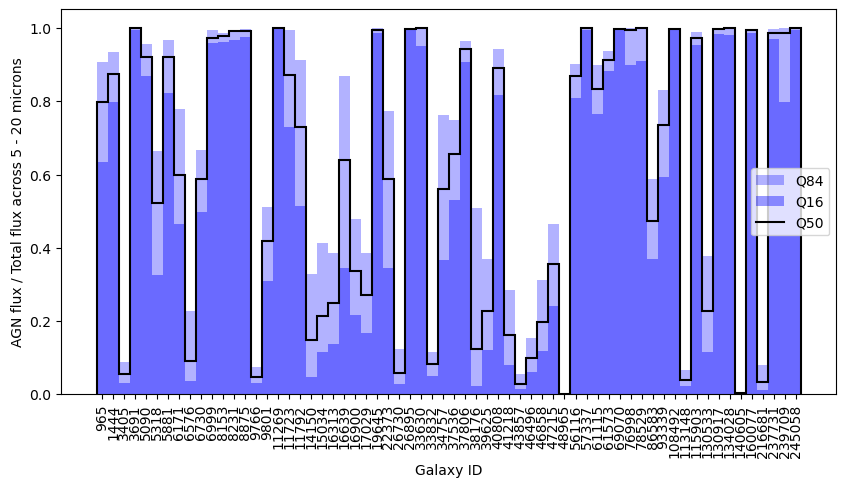

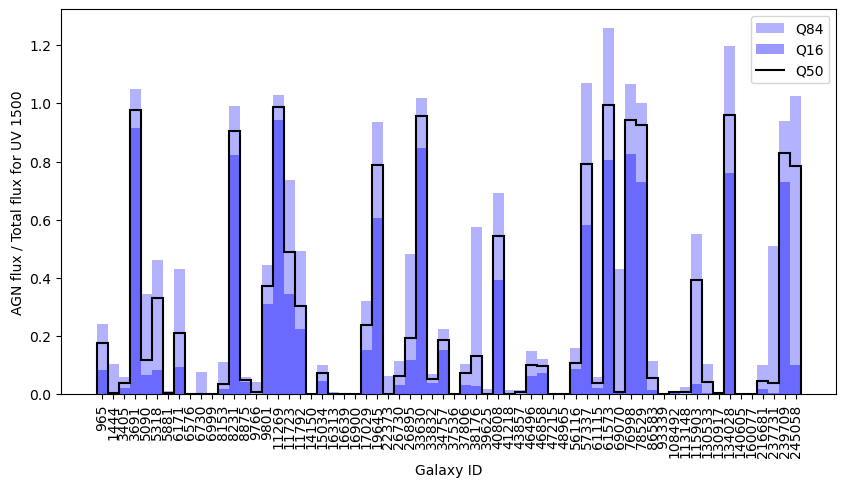

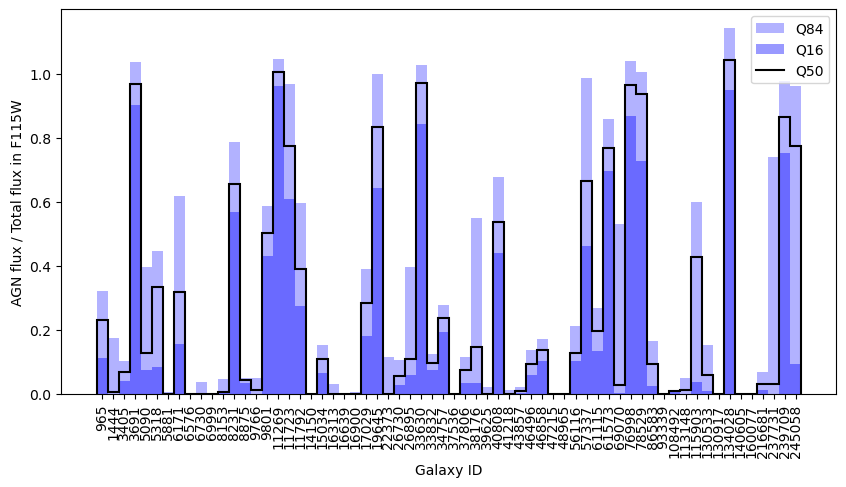

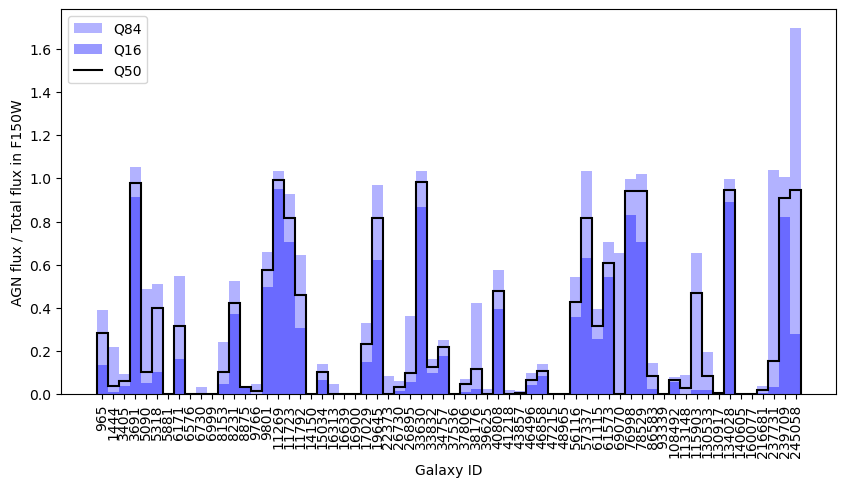

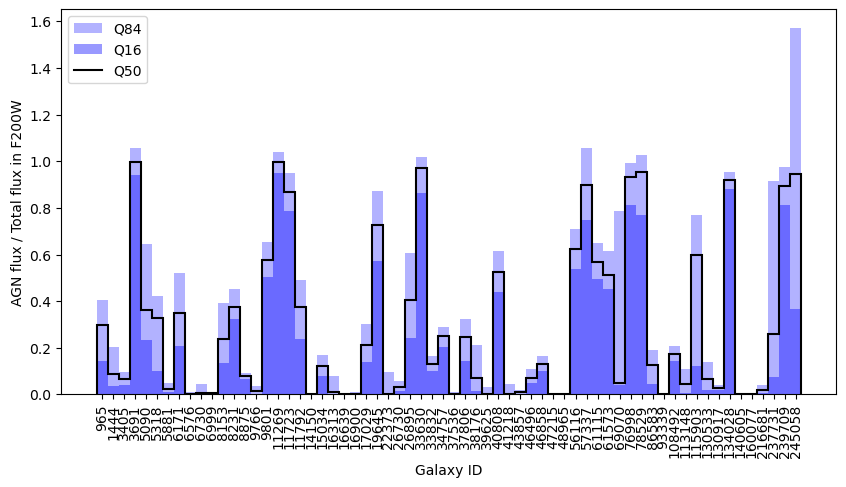

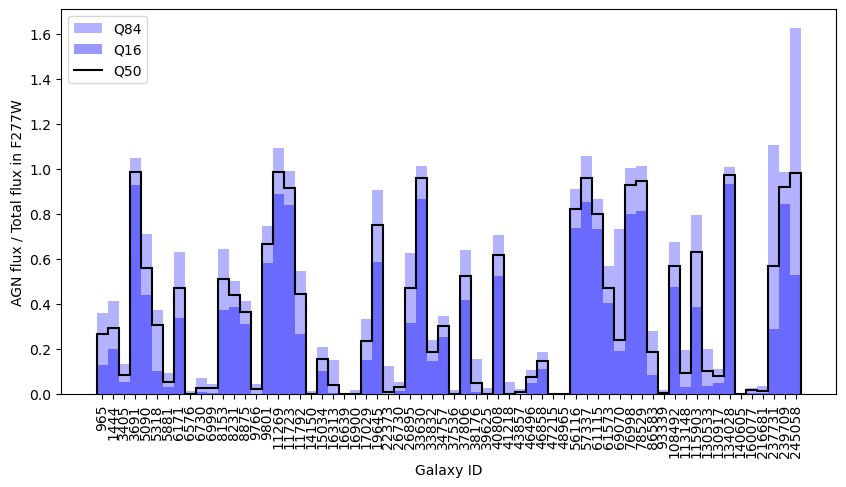

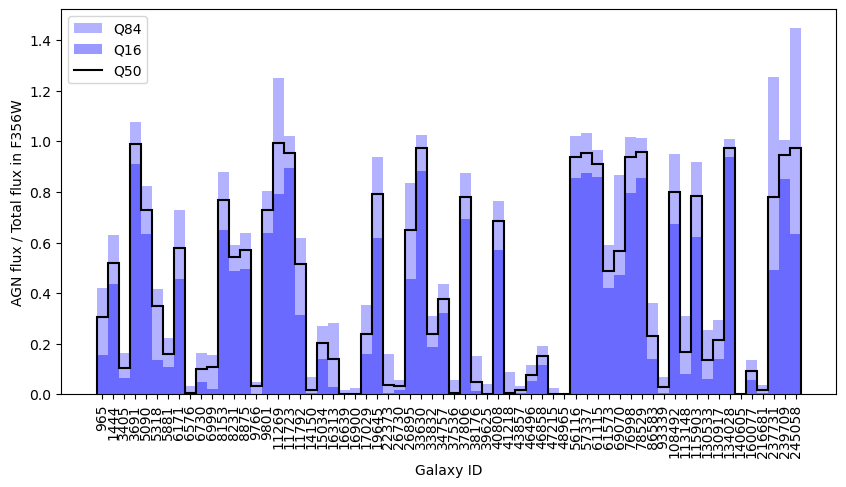

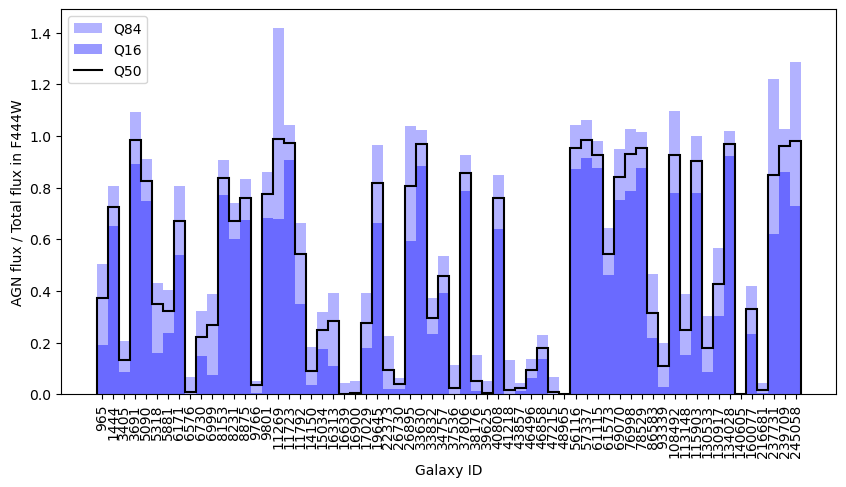

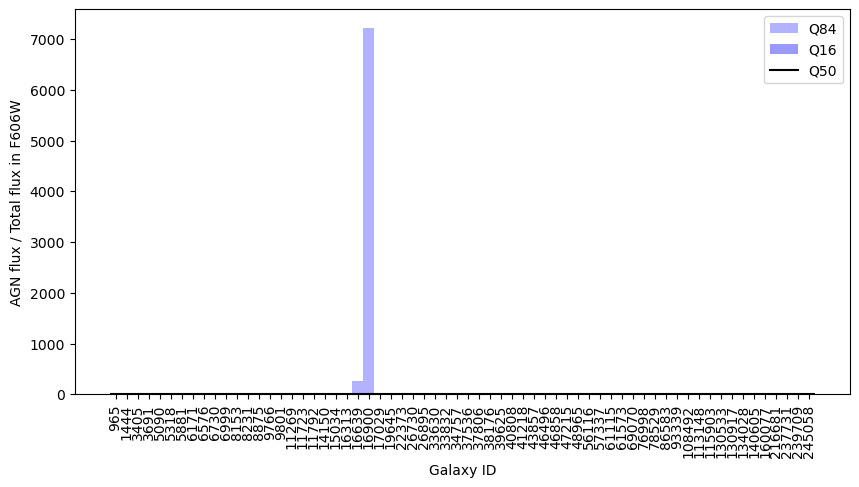

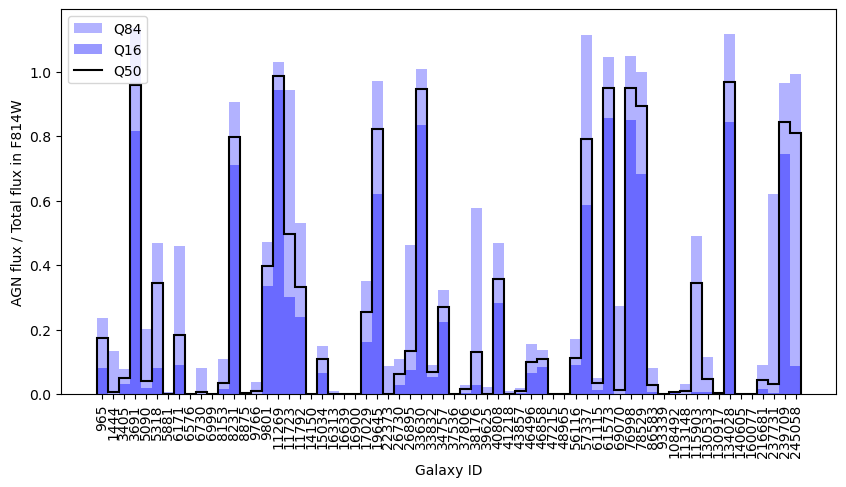

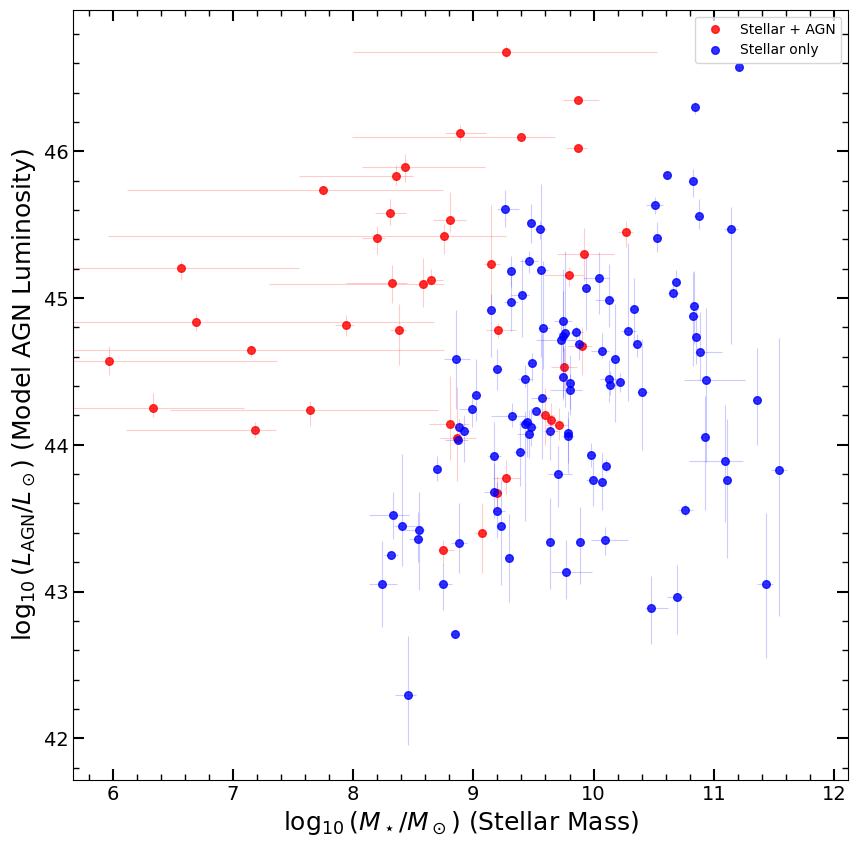

100%|██████████| 2000/2000 [00:03<00:00, 609.14it/s]



For plot below: 
Reduced chi squared = 0.586
Intrinsic scatter from fit = 0.001
NMAD of normalised residuals = 0.270


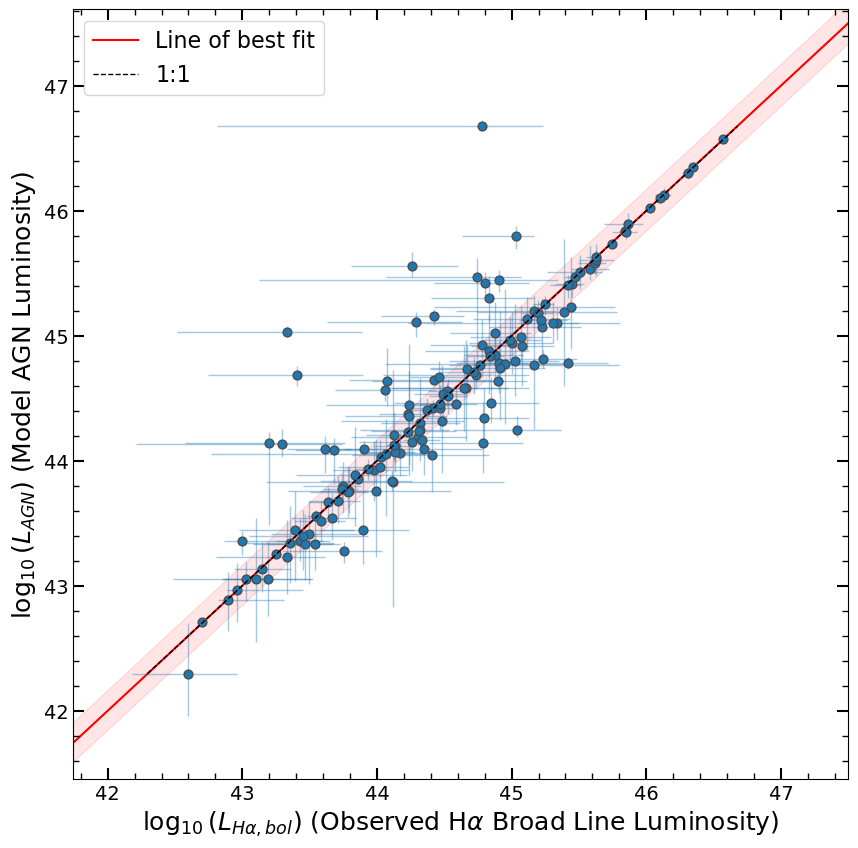

Line of best fit equation: 


<IPython.core.display.Math object>

In [76]:
if __name__ == "__main__":
    #-----------------------------------------------------------------------------------------------------------------------
    stellar_only_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/Data_inputs/ProSpect_data/bc03_snorm_astro_cat.csv")
    stellar_only_table.rename_column("ID", "SURVEY_ID")
    # Contains posterior data from stellar only fit as well as fitted photometry (anything with AGN in the colname has zeros for consistency)

    stellar_AGN_Lbol_prior_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/Data_inputs/ProSpect_data/bc03_snorm_fritz_lbol_prior_astro_cat.csv")
    stellar_AGN_Lbol_prior_table.rename_column("ID", "SURVEY_ID")
    # Contains posterior data from stellar only fit as well as fitted photometry (anything with AGN in the colname has zeros for consistency)

    #-----------------------------------------------------------------------------------------------------------------------
    stellar_only_and_galaxy_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits")

    stellar_AGN_and_galaxy_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_AGN_galaxy_table.fits")

    #-----------------------------------------------------------------------------------------------------------------------
    filtered_AGN_table_ids = AGNfrac_histograms(stellar_only_and_galaxy_table, stellar_AGN_and_galaxy_table)
    # The survey ids of the galaxies that preferred the AGN fit after the final cut

    final_filtered_SED_table = final_filter(stellar_only_and_galaxy_table, stellar_AGN_and_galaxy_table, filtered_AGN_table_ids)

    plot_AGNlum(final_filtered_SED_table)
    